Modelo guardado en: gb_low\gb_low_model.pkl
Informe guardado en: gb_low\evaluacion_umbral_0.25.txt
Informe guardado en: gb_low\evaluacion_umbral_0.4.txt
Informe guardado en: gb_low\evaluacion_umbral_0.5.txt
Informe guardado en: gb_low\evaluacion_umbral_0.75.txt
Informe guardado en: gb_low\evaluacion_umbral_0.77.txt
Informe guardado en: gb_low\evaluacion_umbral_0.85.txt
Informe guardado en: gb_low\evaluacion_umbral_0.95.txt


c:\Users\emima\OneDrive\Escritorio\proyecto delfos\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  useless because the odds of having the condition did not change after the
c:\Users\emima\OneDrive\Escritorio\proyecto delfos\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  useless because the odds of having the condition did not change after the
c:\Users\emima\OneDrive\Escritorio\proyecto delfos\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  useless beca

Aquí nos quedamos
Informe guardado en: gb_low\importancia_variables_gb_low.txt
ROC guardada en: gb_low\ROC_gb_low.png
Ahora comienza lo bueno
Resultados guardados en: gb_low\backtest_gb_low.csv


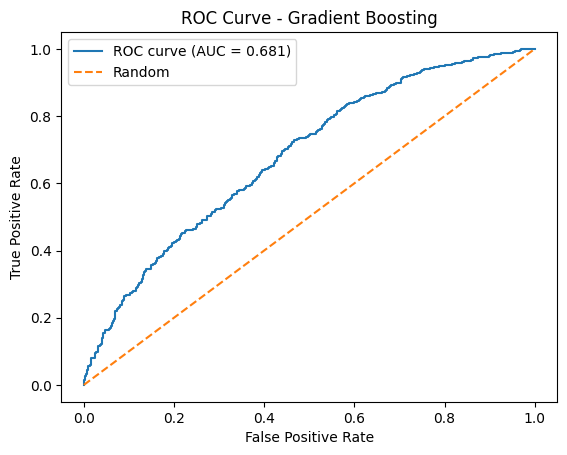

In [14]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix
import os
import pickle
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Crear carpeta si no existe
output_dir = "gb_low"
os.makedirs(output_dir, exist_ok=True)


sol = pd.read_csv('sol_dinamicas.csv')
btc = pd.read_csv('btc_dinamicas.csv')
eth = pd.read_csv('eth_dinamicas.csv')
xrp = pd.read_csv('xrp_dinamicas.csv')

sol['cripto'] = 'SOL'
btc['cripto'] = 'BTC'
eth['cripto'] = 'ETH'
xrp['cripto'] = 'XRP'

data = pd.concat([sol, btc, eth, xrp], ignore_index=True)

corte = data['low_return'].median()
data['target_low'] = data['target_low'].apply(lambda x: 1 if x < corte else 0)

data = data.dropna()

# 🔹 One Hot Encoding
data = pd.get_dummies(data, columns=['cripto'], prefix='cripto')

df = data.drop(columns={'date','open','high','close','low','target_high'})


X = df.drop(columns='target_low')
y = df['target_low']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

gb_low = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

gb_low.fit(X_train, y_train)

# Guardar modelo
model_path = os.path.join(output_dir, "gb_low_model.pkl")

with open(model_path, "wb") as f:
    pickle.dump(gb_low, f)

print(f"Modelo guardado en: {model_path}")

y_prob = gb_low.predict_proba(X_test)[:, 1]

with open("gb_low/gb_low_columns.pkl", "wb") as f:
    pickle.dump(X.columns.tolist(), f)


# Reporte

def evaluar_umbral(y_true, y_prob, umbral, output_dir="gb_low"):
    # Crear carpeta si no existe

    y_pred = (y_prob >= umbral).astype(int)

    cm = confusion_matrix(y_true, y_pred)
    cr = classification_report(y_true, y_pred)

    file_path = os.path.join(output_dir, f"evaluacion_umbral_{umbral}.txt")

    with open(file_path, "w", encoding="utf-8") as f:
        f.write(f"UMBRAL = {umbral}\n\n")
        f.write("CONFUSION MATRIX\n")
        f.write(str(cm))
        f.write("\n\nCLASSIFICATION REPORT\n")
        f.write(cr)

    print(f"Informe guardado en: {file_path}")

    

evaluar_umbral(y_test, y_prob, 0.25)
evaluar_umbral(y_test, y_prob, 0.4)
evaluar_umbral(y_test, y_prob, 0.5)
evaluar_umbral(y_test, y_prob, 0.75)
evaluar_umbral(y_test, y_prob, 0.77)
evaluar_umbral(y_test, y_prob, 0.85)
evaluar_umbral(y_test, y_prob, 0.95)


# Importancia de cripto



# Importancias
importancias = pd.Series(
    gb_low.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

# Importancias de cripto (one-hot)
importancias_cripto = importancias[importancias.index.str.startswith('cripto_')]

# Guardar informe
file_path = os.path.join(output_dir, "importancia_variables_gb_low.txt")

with open(file_path, "w", encoding="utf-8") as f:
    f.write("IMPORTANCIA DE VARIABLES - GRADIENT BOOSTING (LOW)\n\n")
    f.write("TOP VARIABLES GLOBALES\n")
    f.write(importancias.to_string())
    f.write("\n\nIMPORTANCIA VARIABLES CRIPTO (ONE HOT)\n")
    f.write(importancias_cripto.to_string())

print("Aquí nos quedamos")
print(f"Informe guardado en: {file_path}")


# Curva ROC
import os
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc



# Calcular ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Dibujar
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', label='Random')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Gradient Boosting')
plt.legend()

# Guardar imagen
file_path = os.path.join(output_dir, "ROC_gb_low.png")
plt.savefig(file_path, dpi=300, bbox_inches='tight')



print(f"ROC guardada en: {file_path}")


# Monitoring

df_eval = pd.DataFrame({
    'y_true': y_test.values,
    'y_prob': y_prob
})

df_eval['decile'] = pd.qcut(
    df_eval['y_prob'],
    10,
    labels=False,
    duplicates='drop'
)

# Ordenar: decil 0 = mayor probabilidad
df_eval['decile'] = 9 - df_eval['decile']

deciles = (
    df_eval
    .groupby('decile')
    .agg(
        total=('y_true', 'count'),
        positivos=('y_true', 'sum'),
        score_mean=('y_prob', 'mean')
    )
    .reset_index()
)

deciles['tasa_positivos'] = deciles['positivos'] / deciles['total']

# Global
tasa_global = df_eval['y_true'].mean()

# Uplift
deciles['uplift'] = deciles['tasa_positivos'] / tasa_global

deciles['positivos_acum'] = deciles['positivos'].cumsum()
deciles['total_acum'] = deciles['total'].cumsum()

deciles['tasa_acum'] = deciles['positivos_acum'] / deciles['total_acum']
deciles['uplift_acum'] = deciles['tasa_acum'] / tasa_global

# Separar positivos y negativos
df_eval['negativos'] = 1 - df_eval['y_true']

ks_table = (
    df_eval
    .groupby('decile')
    .agg(
        pos=('y_true', 'sum'),
        neg=('negativos', 'sum')
    )
    .sort_index()
    .reset_index()
)

# Acumulados
ks_table['pos_acum'] = ks_table['pos'].cumsum()
ks_table['neg_acum'] = ks_table['neg'].cumsum()

# Normalizar
ks_table['tpr'] = ks_table['pos_acum'] / ks_table['pos'].sum()
ks_table['fpr'] = ks_table['neg_acum'] / ks_table['neg'].sum()

# KS
ks_table['ks'] = ks_table['tpr'] - ks_table['fpr']
ks_value = ks_table['ks'].abs().max()



# Guardar CSV dentro de la carpeta
deciles.to_csv(
    os.path.join(output_dir, "Monitoring.csv"),
    index=False
)


prod = data[data['cripto_SOL'] == True].reset_index().copy()

prod_features = prod[X.columns]
prod['predict'] = gb_low.predict_proba(prod_features)[:, 1]

prod['actual_high'] = prod['high_return'].shift(-1)
prod['actual_low'] = prod['low_return'].shift(-1)
prod['actual_close'] = prod['close_return'].shift(-1)

umbrales_low = np.linspace(0.9,0.99,10)
umbrales_high = np.linspace(1,1.05,11)
umbrales_decision = np.linspace(0,1,21)

print("Ahora comienza lo bueno")

dic_c = {}
n = len(prod)
for umbral_high in umbrales_high:
  for umbral_low in umbrales_low:
    for umbral_decision in umbrales_decision:
      c = 1
      for i in range(n-1):
        actual_high = prod.loc[prod.index[i], 'actual_high']
        actual_low = prod.loc[prod.index[i], 'actual_low']
        actual_close = prod.loc[prod.index[i], 'actual_close']
        pred = prod.loc[prod.index[i], 'predict']
        if pred < umbral_decision:
          if actual_low < umbral_low:
            c *= umbral_low
          elif actual_high > umbral_high:
            c *= umbral_high
          else:
            c*= 0.97
        dic_c[(umbral_high,umbral_low, umbral_decision)] = c

umbral_max, umbral_min = max(dic_c, key=dic_c.get), min(dic_c, key=dic_c.get)

# Desempeño



umbral_high = umbral_max[0]
umbral_low = umbral_max[1]

resultados = []

for j in range(1, 6):
    prod_date = prod[
        (prod['date'] > f'202{j}-01-01') &
        (prod['date'] < f'202{j+1}-01-01')
    ].reset_index(drop=True)

    n = len(prod_date)
    c = 1

    for i in range(n - 1):
        actual_high = prod_date.loc[i, 'actual_high']
        actual_low = prod_date.loc[i, 'actual_low']
        actual_close = prod_date.loc[i, 'actual_close']
        pred = prod_date.loc[i, 'predict']

        if pred < umbral_max[2]:
            if actual_low < umbral_low:
                c *= umbral_low
            elif actual_high > umbral_high:
                c *= umbral_high
            else:
                c *= actual_close

    resultados.append({
        'year_start': f'202{j}-01-01',
        'year_end': f'202{j+1}-01-01',
        'capital_final': c
    })

# Convertir a DataFrame
df_resultados = pd.DataFrame(resultados)


umbral_max = list(umbral_max)

with open("gb_low/umbral_gb_low_columns.pkl", "wb") as f:
    pickle.dump(umbral_max, f)



# Guardar CSV
file_path = os.path.join(output_dir, "backtest_gb_low.csv")
df_resultados.to_csv(file_path, index=False)

print(f"Resultados guardados en: {file_path}")


In [ ]:
from datetime import datetime
import pandas as pd
from datetime import datetime, timedelta, timezone
from binance.client import Client
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import hmean




# Inicializar el cliente con tus credenciales
api_key = 'cAGsQPkvI5sxkMt1qTJY7ancjALp1EeabYyF8GltqJ8KuOKvgfZH7aKzYHyQc9X8'
api_secret = 'qkj0jJxLcbzEvpyJvYfww5jzYkv8ExYayhT7mXGbFfeWwT0bnH8VrolE4tNr1WO0'

client = Client(api_key, api_secret)

from binance.client import Client
from binance.exceptions import BinanceAPIException
import numpy as np
import time
import threading


client = Client(api_key, api_secret)

# 🔹 Sincronizar reloj
server_time = client.get_server_time()["serverTime"]
local_time = int(time.time() * 1000)
client.timestamp_offset = server_time - local_time

# 🔹 Función para crear orden de venta LIMIT
def create_sell_order(symbol, sell_price):
    try:
        # Obtener saldo disponible del activo base
        base_asset = symbol[:-4]  # asumiendo par tipo XXXUSDC
        balance = client.get_asset_balance(asset=base_asset)
        qty = float(balance['free'])

        if qty <= 0:
            print(f"No tienes {base_asset} disponible para vender.")
            return None

        # Ajustar cantidad según stepSize y minNotional
        symbol_info = client.get_symbol_info(symbol)
        step_size = None
        min_notional = None

        for f in symbol_info['filters']:
            if f['filterType'] == 'LOT_SIZE':
                step_size = float(f['stepSize'])
            elif f['filterType'] == 'NOTIONAL':
                min_notional = float(f['minNotional'])

        if step_size is None or min_notional is None:
            raise ValueError("No se pudo obtener stepSize o minNotional del par")

        qty_to_sell = np.floor(qty / step_size) * step_size

        if qty_to_sell * sell_price < min_notional:
            raise ValueError(f"Valor total de la orden ({qty_to_sell*sell_price:.2f}) menor que minNotional ({min_notional})")

        order = client.create_order(
            symbol=symbol,
            side="SELL",
            type="LIMIT",
            quantity=qty_to_sell,
            price=str(sell_price),
            timeInForce="GTC"
        )

        print(f"✅ Orden de venta creada para {symbol} a {sell_price}:")
        print(order)
        return order

    except BinanceAPIException as e:
        print("❌ Error de API al crear orden de venta:", e)
    except Exception as e:
        print("❌ Otro error al crear orden de venta:", e)

# 🔹 Función para cancelar orden de venta abierta
def cancel_sell_order(symbol):
    try:
        # Obtener todas las órdenes abiertas del par
        open_orders = client.get_open_orders(symbol=symbol)
        if not open_orders:
            print(f"No hay órdenes abiertas para {symbol}.")
            return None

        # Cancelar la primera orden encontrada
        order_id = open_orders[0]['orderId']
        canceled_order = client.cancel_order(symbol=symbol, orderId=order_id)
        print(f"✅ Orden cancelada para {symbol}:")
        print(canceled_order)
        return canceled_order

    except BinanceAPIException as e:
        print("❌ Error de API al cancelar orden:", e)
    except Exception as e:
        print("❌ Otro error al cancelar orden:", e)


def get_binance_time(client, formatted=True):
    """
    Devuelve la hora actual del servidor de Binance.
    
    Args:
        client: instancia de Client de Binance
        formatted (bool):
            True  -> devuelve string formateado
            False -> devuelve datetime
    
    Returns:
        str o datetime
    """
    server_time = client.get_server_time()["serverTime"]  # milisegundos
    dt = datetime.fromtimestamp(server_time / 1000)

    if formatted:
        return dt.strftime("%H:%M:%S")
    else:
        return dt




# 🔹 Función para comprar todo el saldo disponible de la moneda de cotización
def buy_with_full_quote(symbol, fee_margin=0.995):
    """
    Ejecuta orden MARKET comprando con todo el saldo disponible de la moneda de cotización.
    
    Args:
        symbol (str): Par de trading, por ejemplo "SOLUSDC"
        fee_margin (float): Margen para dejar parte del saldo y cubrir fees (por defecto 0.995)
    
    Returns:
        float: Precio medio de ejecución de la compra (approx)
        dict: Detalles completos de la orden
    """
    # 🔹 Sincronizar reloj
    server_time = client.get_server_time()["serverTime"]
    local_time = int(time.time() * 1000)
    client.timestamp_offset = server_time - local_time
    
    try:
        # Determinar la moneda de cotización (la parte después de XXX)
        quote_asset = symbol[-4:]  # asumiendo par tipo XXXUSDC

        # Obtener saldo disponible
        balance = client.get_asset_balance(asset=quote_asset)
        free_amount = float(balance['free'])

        if free_amount <= 0:
            print(f"No tienes {quote_asset} disponible para comprar.")
            return None, None

        # Ajustar cantidad a usar según fee_margin
        amount_to_use = round(free_amount * fee_margin, 2)

        # Crear orden MARKET
        order = client.create_order(
            symbol=symbol,
            side="BUY",
            type="MARKET",
            quoteOrderQty=amount_to_use
        )

        # Calcular precio medio de ejecución
        fills = order.get('fills', [])
        if fills:
            total_cost = sum(float(f['price']) * float(f['qty']) for f in fills)
            total_qty = sum(float(f['qty']) for f in fills)
            avg_price = total_cost / total_qty if total_qty > 0 else 0
        else:
            avg_price = 0

        print(f"✅ Orden MARKET ejecutada en {symbol}")
        print(f"Cantidad gastada: {amount_to_use} {quote_asset}, precio medio: {avg_price:.4f}")
        return avg_price, order

    except BinanceAPIException as e:
        print("❌ Error de API:", e)
        return None, None
    except Exception as e:
        
        print("❌ Otro error:", e)
        return None, None



In [ ]:
def check_time(hour = 14):
    return get_binance_time(client, formatted=True)[:2] == str(hour)

In [43]:
get_binance_time(client, formatted=True)[:5]

'20:45'

In [46]:
def check_sell_execution(symbol, order_id=None):
    """
    Comprueba si una orden de venta fue ejecutada.

    Args:
        symbol (str): Par de trading (ej. "SOLUSDC")
        order_id (int, optional): ID específico de la orden

    Returns:
        bool: True si está FILLED
        float: Precio medio de ejecución (si aplica)
        dict: Datos completos de la orden
    """

    try:
        # Si se pasa order_id, consultamos esa orden concreta
        if order_id:
            order = client.get_order(symbol=symbol, orderId=order_id)
        else:
            # Si no, revisamos historial reciente
            orders = client.get_all_orders(symbol=symbol, limit=5)
            if not orders:
                print("No hay órdenes registradas.")
                return False, None, None
            order = orders[-1]  # última orden

        status = order["status"]

        if status == "FILLED":
            print("✅ Orden de venta ejecutada.")

            # Calcular precio medio real
            trades = client.get_my_trades(symbol=symbol)

            # Filtrar trades de esa orderId
            relevant_trades = [t for t in trades if t["orderId"] == order["orderId"]]

            total_qty = sum(float(t["qty"]) for t in relevant_trades)
            total_quote = sum(float(t["quoteQty"]) for t in relevant_trades)

            avg_price = total_quote / total_qty if total_qty > 0 else 0

            print(f"Precio medio ejecución: {avg_price:.4f}")

            return True, avg_price, order

        elif status in ["NEW", "PARTIALLY_FILLED"]:
            print("⏳ Orden aún no ejecutada completamente.")
            return False, None, order

        else:
            print(f"⚠️ Estado de la orden: {status}")
            return False, None, order

    except BinanceAPIException as e:
        print("❌ Error de API:", e)
        return False, None, None
    except Exception as e:
        print("❌ Otro error:", e)
        return False, None, None


In [49]:
check_sell_execution('SOLUSDC')

✅ Orden de venta ejecutada.
Precio medio ejecución: 84.6700


(True,
 84.67,
 {'symbol': 'SOLUSDC',
  'orderId': 3346776199,
  'orderListId': -1,
  'clientOrderId': 'and_2fa96777669e400ba015588be4090014',
  'price': '84.67000000',
  'origQty': '1.55500000',
  'executedQty': '1.55500000',
  'cummulativeQuoteQty': '131.66185000',
  'status': 'FILLED',
  'timeInForce': 'GTC',
  'type': 'LIMIT',
  'side': 'SELL',
  'stopPrice': '0.00000000',
  'icebergQty': '0.00000000',
  'time': 1771603979380,
  'updateTime': 1771604000213,
  'isWorking': True,
  'workingTime': 1771603979380,
  'origQuoteOrderQty': '0.00000000',
  'selfTradePreventionMode': 'EXPIRE_MAKER'})

In [2]:
pip install scikit-learn


  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------  7.9/8.0 MB 53.9 MB/s eta 0:00:01
   ---------------------------------------- 8.0/8.0 MB 41.5 MB/s eta 0:00:00
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import threading
from datetime import datetime
import pandas as pd
from datetime import datetime, timedelta, timezone
from binance.client import Client
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import hmean
import pickle
import sklearn



# Inicializar el cliente con tus credenciales
api_key = 'cAGsQPkvI5sxkMt1qTJY7ancjALp1EeabYyF8GltqJ8KuOKvgfZH7aKzYHyQc9X8'
api_secret = 'qkj0jJxLcbzEvpyJvYfww5jzYkv8ExYayhT7mXGbFfeWwT0bnH8VrolE4tNr1WO0'

client = Client(api_key, api_secret)

from binance.client import Client
from binance.exceptions import BinanceAPIException
import numpy as np
import time
import threading


client = Client(api_key, api_secret)

# 🔹 Sincronizar reloj
server_time = client.get_server_time()["serverTime"]
local_time = int(time.time() * 1000)
client.timestamp_offset = server_time - local_time

def predict(symbol):

    date_end = None
    period = 370
    hour = 10 

    ticker = symbol
    if date_end is None:
        date_end = datetime.now(timezone.utc)
    else:
        date_end = date_end
    date_start = date_end - timedelta(days=period)


    intervalo_horas = Client.KLINE_INTERVAL_1HOUR


    # Obtener datos históricos
    start_timestamp = int(date_start.timestamp() * 1000)
    end_timestamp = int(date_end.timestamp() * 1000)

    klines = client.get_historical_klines(ticker, intervalo_horas, str(start_timestamp), str(end_timestamp))

    if not klines:
        raise ValueError("No se obtuvieron datos históricos para la criptomoneda y el período especificados.")

    data = []

    def timestamp_to_utc(ts):
        return datetime.fromtimestamp(ts / 1000, tz=timezone.utc)

    for kline in klines:
        data.append({
            'time': timestamp_to_utc(float(kline[0])),
            'open': float(kline[1]),
            'high': float(kline[2]),
            'low': float(kline[3]),
            'close': float(kline[4]),
            'volume': float(kline[5]),
        })

    aux = pd.DataFrame(data)

    aux['date'] = pd.to_datetime(aux['time'])
    aux['date'] = aux['date'].shift(hour)
    aux['day'] = aux['day'] = aux['date'].dt.date

    df = aux.groupby('day').agg(
        open = ('open', 'first'),
        close =('close', 'last'),
        high = ('high', 'max'),
        low =('low', 'min'),
        volume =('volume','first'),
        date = ('day','first')
        )

    df['high_return'] = df['high']/ df['open']
    df['low_return'] = df['low']/ df['open']
    df['close_return'] = df['close']/ df['open']
    df['volatility'] = df['high_return'] - df['low_return']
    def combinations(l):
        l_final = []
        n = len(l)
        for i in range(n-1):
            for j in range(i+1,n):
                l_final.append((l[i],l[j]))
        return l_final 

    rachas = [1,3,7,14,30,90,180,360]           

    dinamicas = combinations(rachas)
            

    for r in rachas:
        df[f'high_mean_{r}'] = df['high_return'].rolling(r).mean()
        df[f'low_mean_{r}'] = df['low_return'].rolling(r).mean()
        df[f'close_mean_{r}'] = df['close_return'].rolling(r).mean()
        df[f'volatility_mean_{r}'] = df['volatility'].rolling(r).mean()



    for d in dinamicas:
        a,b = d
        df[f'high_dinamica_mean_{a}_{b}'] = (df[f'high_mean_{a}'] / df[f'high_mean_{b}']) -1
        df[f'volatility_dinamica_mean_{a}_{b}'] =(df[f'volatility_mean_{a}'] / df[f'volatility_mean_{b}']) - 1
        df[f'low_dinamica_mean_{a}_{b}'] = -((df[f'low_mean_{a}'] / df[f'low_mean_{b}']) -1)
        df[f'close_dinamica_mean_{a}_{b}'] = (df[f'close_mean_{a}'] / df[f'close_mean_{b}']) -1
        df[f'high_dinamica_mean_{a}_{b}_modified'] = df[f'high_mean_{a}']**2 / df[f'high_mean_{b}']
        df[f'high_pendiente_{a}_{b}'] = df[f'high_dinamica_mean_{a}_{b}'].diff()
        df[f'low_pendiente_{a}_{b}'] = df[f'low_dinamica_mean_{a}_{b}'].diff()
        df[f'close_pendiente_{a}_{b}'] = df[f'close_dinamica_mean_{a}_{b}'].diff()
        df[f'volatility_pendiente_{a}_{b}'] = df[f'volatility_dinamica_mean_{a}_{b}'].diff()

    df['cripto_SOL'] = True
    df['cripto_BTC'] = False
    df['cripto_ETH'] = False
    df['cripto_XRP'] = False

    df = df.dropna()
    
    data = df.drop(columns={'date','open','high','close','low'})

    
    print('checkpoint')
    with open("gb_low/gb_low_model.pkl", "rb") as f:
        gb_low = pickle.load(f)
    print('checkpoint')
    with open("gb_low/gb_low_columns.pkl", "rb") as f:
        cols = pickle.load(f)
    print('checkpoint')     
    with open("gb_low/umbral_gb_low_columns.pkl", "rb") as f:
        umbral_max = pickle.load(f)
    print('checkpoint')
    pred = gb_low.predict_proba(data[cols].tail(1))[:, 1]
    pred_bool = pred > umbral_max[2]
    openday = df['open'].tail(1)
    virtual_close = openday*umbral_max[0]

    return pred, pred_bool


# 🔹 Función para crear orden de venta LIMIT
def create_sell_order(symbol, sell_price):
    try:
        # Obtener saldo disponible del activo base
        base_asset = symbol[:-4]  # asumiendo par tipo XXXUSDC
        balance = client.get_asset_balance(asset=base_asset)
        qty = float(balance['free'])

        if qty <= 0:
            print(f"No tienes {base_asset} disponible para vender.")
            return None

        # Ajustar cantidad según stepSize y minNotional
        symbol_info = client.get_symbol_info(symbol)
        step_size = None
        min_notional = None

        for f in symbol_info['filters']:
            if f['filterType'] == 'LOT_SIZE':
                step_size = float(f['stepSize'])
            elif f['filterType'] == 'NOTIONAL':
                min_notional = float(f['minNotional'])

        if step_size is None or min_notional is None:
            raise ValueError("No se pudo obtener stepSize o minNotional del par")

        qty_to_sell = np.floor(qty / step_size) * step_size

        if qty_to_sell * sell_price < min_notional:
            raise ValueError(f"Valor total de la orden ({qty_to_sell*sell_price:.2f}) menor que minNotional ({min_notional})")

        order = client.create_order(
            symbol=symbol,
            side="SELL",
            type="LIMIT",
            quantity=qty_to_sell,
            price=str(sell_price),
            timeInForce="GTC"
        )

        print(f"✅ Orden de venta creada para {symbol} a {sell_price}:")
        print(order)
        return order

    except BinanceAPIException as e:
        print("❌ Error de API al crear orden de venta:", e)
    except Exception as e:
        print("❌ Otro error al crear orden de venta:", e)

# 🔹 Función para cancelar orden de venta abierta
def cancel_sell_order(symbol):
    try:
        # Obtener todas las órdenes abiertas del par
        open_orders = client.get_open_orders(symbol=symbol)
        if not open_orders:
            print(f"No hay órdenes abiertas para {symbol}.")
            return None

        # Cancelar la primera orden encontrada
        order_id = open_orders[0]['orderId']
        canceled_order = client.cancel_order(symbol=symbol, orderId=order_id)
        print(f"✅ Orden cancelada para {symbol}:")
        print(canceled_order)
        return canceled_order

    except BinanceAPIException as e:
        print("❌ Error de API al cancelar orden:", e)
    except Exception as e:
        print("❌ Otro error al cancelar orden:", e)


def get_binance_time(client, formatted=True):
    """
    Devuelve la hora actual del servidor de Binance.
    
    Args:
        client: instancia de Client de Binance
        formatted (bool):
            True  -> devuelve string formateado
            False -> devuelve datetime
    
    Returns:
        str o datetime
    """
    server_time = client.get_server_time()["serverTime"]  # milisegundos
    dt = datetime.fromtimestamp(server_time / 1000)

    if formatted:
        return dt.strftime("%H:%M:%S")
    else:
        return dt




# 🔹 Función para comprar todo el saldo disponible de la moneda de cotización
def buy_with_full_quote(symbol, fee_margin=0.995, timeout=15):
    """
    Ejecuta orden MARKET comprando con todo el saldo disponible y
    no termina hasta que la orden esté completamente ejecutada.

    Args:
        symbol (str): Par de trading, por ejemplo "SOLUSDC"
        fee_margin (float): Margen para fees
        timeout (int): Segundos máximos de espera

    Returns:
        float: Precio medio real de ejecución
        dict: Orden completa
    """

    # 🔹 Sincronizar reloj
    server_time = client.get_server_time()["serverTime"]
    local_time = int(time.time() * 1000)
    client.timestamp_offset = server_time - local_time

    try:
        quote_asset = symbol[-4:]
        balance = client.get_asset_balance(asset=quote_asset)
        free_amount = float(balance['free'])

        if free_amount <= 0:
            print(f"No tienes {quote_asset} disponible.")
            return None, None

        amount_to_use = round(free_amount * fee_margin, 2)

        # 🔹 Crear orden MARKET
        order = client.create_order(
            symbol=symbol,
            side="BUY",
            type="MARKET",
            quoteOrderQty=amount_to_use
        )

        order_id = order["orderId"]

        print("⏳ Esperando confirmación de ejecución...")

        # 🔹 Esperar hasta que esté FILLED
        start_time = time.time()

        while True:
            current_order = client.get_order(symbol=symbol, orderId=order_id)
            status = current_order["status"]

            if status == "FILLED":
                break

            if time.time() - start_time > timeout:
                raise TimeoutError("La orden no se ejecutó dentro del tiempo esperado.")

            time.sleep(10)

        # 🔹 Calcular precio medio real usando trades
        trades = client.get_my_trades(symbol=symbol)

        relevant_trades = [t for t in trades if t["orderId"] == order_id]

        total_qty = sum(float(t["qty"]) for t in relevant_trades)
        total_quote = sum(float(t["quoteQty"]) for t in relevant_trades)

        avg_price = total_quote / total_qty if total_qty > 0 else 0

        print(f"✅ Compra ejecutada completamente en {symbol}")
        print(f"Precio medio real: {avg_price:.6f}")

        return avg_price, current_order

    except BinanceAPIException as e:
        print("❌ Error de API:", e)
        return None, None
    except Exception as e:
        print("❌ Error:", e)
        return None, None


def check_sell_execution(symbol, order_id=None):
    """
    Comprueba si una orden de venta fue ejecutada.

    Args:
        symbol (str): Par de trading (ej. "SOLUSDC")
        order_id (int, optional): ID específico de la orden

    Returns:
        bool: True si está FILLED
        float: Precio medio de ejecución (si aplica)
        dict: Datos completos de la orden
    """

    try:
        # Si se pasa order_id, consultamos esa orden concreta
        if order_id:
            order = client.get_order(symbol=symbol, orderId=order_id)
        else:
            # Si no, revisamos historial reciente
            orders = client.get_all_orders(symbol=symbol, limit=5)
            if not orders:
                print("No hay órdenes registradas.")
                return False
            order = orders[-1]  # última orden

        status = order["status"]

        if status == "FILLED":
            print("✅ Orden de venta ejecutada.")

            # Calcular precio medio real
            trades = client.get_my_trades(symbol=symbol)

            # Filtrar trades de esa orderId
            relevant_trades = [t for t in trades if t["orderId"] == order["orderId"]]

            total_qty = sum(float(t["qty"]) for t in relevant_trades)
            total_quote = sum(float(t["quoteQty"]) for t in relevant_trades)

            avg_price = total_quote / total_qty if total_qty > 0 else 0

            print(f"Precio medio ejecución: {avg_price:.4f}")

            return True

        elif status in ["NEW", "PARTIALLY_FILLED"]:
            print("⏳ Orden aún no ejecutada completamente.")
            return False

        else:
            print(f"⚠️ Estado de la orden: {status}")
            return False

    except BinanceAPIException as e:
        print("❌ Error de API:", e)
        return False
    except Exception as e:
        print("❌ Otro error:", e)
        return False

def sell_market_order_retry(symbol, retry_interval=15, max_attempts=1000):
    """
    Intenta vender con orden MARKET.
    Si falla o no se vende completamente, reintenta cada X segundos.

    Args:
        symbol (str): Par, ej. "SOLUSDC"
        retry_interval (int): segundos entre intentos
        max_attempts (int): máximo número de intentos

    Returns:
        float: Precio medio de ejecución final
        dict: Última orden ejecutada
    """

    attempts = 0

    while attempts < max_attempts:
        attempts += 1
        print(f"🔄 Intento de venta #{attempts}")

        try:
            base_asset = symbol[:-4]
            balance = client.get_asset_balance(asset=base_asset)
            qty = float(balance['free'])

            if qty <= 0:
                print("✅ No queda saldo. Venta completada.")
                return None, None

            symbol_info = client.get_symbol_info(symbol)

            step_size = None
            for f in symbol_info['filters']:
                if f['filterType'] == 'LOT_SIZE':
                    step_size = float(f['stepSize'])

            if step_size is None:
                raise ValueError("No se pudo obtener stepSize")

            qty_to_sell = np.floor(qty / step_size) * step_size

            if qty_to_sell <= 0:
                print("Cantidad ajustada es 0. Fin.")
                return None, None

            # 🔹 Ejecutar MARKET
            order = client.create_order(
                symbol=symbol,
                side="SELL",
                type="MARKET",
                quantity=qty_to_sell
            )

            # Confirmar ejecución
            order_id = order["orderId"]

            while True:
                current_order = client.get_order(symbol=symbol, orderId=order_id)
                if current_order["status"] == "FILLED":
                    break
                time.sleep(2)

            # Calcular precio medio real
            trades = client.get_my_trades(symbol=symbol)
            relevant_trades = [t for t in trades if t["orderId"] == order_id]

            total_qty = sum(float(t["qty"]) for t in relevant_trades)
            total_quote = sum(float(t["quoteQty"]) for t in relevant_trades)

            avg_price = total_quote / total_qty if total_qty > 0 else 0

            print(f"✅ Venta ejecutada. Precio medio: {avg_price:.6f}")

            # Verificar si aún queda polvo
            balance = client.get_asset_balance(asset=base_asset)
            remaining_qty = float(balance['free'])

            if remaining_qty <= step_size:
                print("🎯 Venta completamente finalizada.")
                return avg_price, order

            print("⚠️ Queda saldo pequeño, reintentando...")

        except Exception as e:
            print("❌ Error en intento de venta:", e)

        print(f"⏳ Esperando {retry_interval} segundos antes de reintentar...")
        time.sleep(retry_interval)

    print("❌ Se alcanzó el máximo de intentos.")
    return None, None


def get_current_price(symbol):
    """
    Devuelve el precio actual de mercado de un símbolo.

    Args:
        symbol (str): Par de trading, ej. "SOLUSDC"

    Returns:
        float: Precio actual
    """
    try:
        ticker = client.get_symbol_ticker(symbol=symbol)
        price = float(ticker["price"])
        return price

    except BinanceAPIException as e:
        print("❌ Error de API al obtener precio:", e)
        return None
    except Exception as e:
        print("❌ Otro error:", e)
        return None

def main(symbol, check_interval=2, target_time="14:00"):

    global active_timer
    from datetime import datetime

    openday = None  # ← importante inicializarlo aquí

    def check_time():
        now = datetime.strptime(
            get_binance_time(client, formatted=True),
            "%H:%M:%S"
        ).time()

        target = datetime.strptime(target_time, "%H:%M").time()

        return now >= target

    cont = check_time()  # estado inicial

    def shot_time():
        nonlocal cont, openday
        global active_timer

        try:
            new_iter = check_time()

            trigger = (not cont) and new_iter
            cont = new_iter

            # 🔥 SOLO se ejecuta una vez cuando cruza la hora
            if trigger:
                print("⏰ Trigger activado")

                pred, pred_bool = predict(symbol)

                if pred < 0.5:
                    if check_sell_execution(symbol, order_id=None):
                        openday, order = buy_with_full_quote(symbol)
                        if openday:
                            create_sell_order(symbol, openday * 1.02)
                    else:
                        print("No se ha comprado porque check_sell_execution dio False")

                else:
                    if check_sell_execution(symbol, order_id=None):
                        sell_market_order_retry(symbol)
                    print("No se ha comprado")

            # 🔻 Lógica de stop-loss continua
            if openday:
                current_price = get_current_price(symbol)
                if current_price < openday * 0.9:
                    print("⚠️ Stop loss activado")
                    cancel_sell_order(symbol)
                    sell_market_order_retry(symbol)
                    openday = None  # evitar repetir venta

            # 🔁 Reprogramar timer
            active_timer = threading.Timer(check_interval, shot_time)
            active_timer.start()

        except Exception as e:
            print("❌ Error:", e)
            active_timer = threading.Timer(5, shot_time)
            active_timer.start()

    # Primera ejecución
    active_timer = threading.Timer(check_interval, shot_time)
    active_timer.start()


In [25]:
def main(symbol, check_interval=2, target_time="14:00"):

    global active_timer
    from datetime import datetime

    openday = None  # ← importante inicializarlo aquí

    def check_time():
        now = datetime.strptime(
            get_binance_time(client, formatted=True),
            "%H:%M:%S"
        ).time()

        target = datetime.strptime(target_time, "%H:%M").time()

        return now >= target

    cont = check_time()  # estado inicial

    def shot_time():
        nonlocal cont, openday
        global active_timer

        try:
            new_iter = check_time()

            trigger = (not cont) and new_iter
            cont = new_iter

            # 🔥 SOLO se ejecuta una vez cuando cruza la hora
            if trigger:
                print("⏰ Trigger activado")

                pred, pred_bool = predict(symbol)

                if pred < 0.5:
                    if check_sell_execution(symbol, order_id=None):
                        openday, order = buy_with_full_quote(symbol)
                        if openday:
                            create_sell_order(symbol, round(openday * 1.02,2))
                    else:
                        print("No se ha comprado porque check_sell_execution dio False")

                else:
                    if check_sell_execution(symbol, order_id=None):
                        sell_market_order_retry(symbol)
                    print("No se ha comprado")

            # 🔻 Lógica de stop-loss continua
            if openday:
                current_price = get_current_price(symbol)
                if current_price < openday * 0.9:
                    print("⚠️ Stop loss activado")
                    cancel_sell_order(symbol)
                    sell_market_order_retry(symbol)
                    openday = None  # evitar repetir venta

            # 🔁 Reprogramar timer
            active_timer = threading.Timer(check_interval, shot_time)
            active_timer.start()

        except Exception as e:
            print("❌ Error:", e)
            active_timer = threading.Timer(5, shot_time)
            active_timer.start()

    # Primera ejecución
    active_timer = threading.Timer(check_interval, shot_time)
    active_timer.start()


In [ ]:
main('SOLUSDC',target_time="20:12")

⏰ Trigger activado


C:\Users\emima\AppData\Local\Temp\ipykernel_6588\3495840561.py:121: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'high_dinamica_mean_{a}_{b}_modified'] = df[f'high_mean_{a}']**2 / df[f'high_mean_{b}']
C:\Users\emima\AppData\Local\Temp\ipykernel_6588\3495840561.py:122: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'high_pendiente_{a}_{b}'] = df[f'high_dinamica_mean_{a}_{b}'].diff()
C:\Users\emima\AppData\Local\Temp\ipykernel_6588\3495840561.py:123: PerformanceWarning: DataFrame is highly fragmented.  This is usually the 

checkpoint
checkpoint
checkpoint
checkpoint
✅ Orden de venta ejecutada.
Precio medio ejecución: 83.1100
⏳ Esperando confirmación de ejecución...
✅ Compra ejecutada completamente en SOLUSDC
Precio medio real: 83.020000
✅ Orden de venta creada para SOLUSDC a 84.68:
{'symbol': 'SOLUSDC', 'orderId': 3350284041, 'orderListId': -1, 'clientOrderId': 'x-HNA2TXFJ8cc3f6e65ea2169fcaa3df', 'transactTime': 1771787531839, 'price': '84.68000000', 'origQty': '1.57700000', 'executedQty': '0.00000000', 'origQuoteOrderQty': '0.00000000', 'cummulativeQuoteQty': '0.00000000', 'status': 'NEW', 'timeInForce': 'GTC', 'type': 'LIMIT', 'side': 'SELL', 'workingTime': 1771787531839, 'fills': [], 'selfTradePreventionMode': 'EXPIRE_MAKER'}


In [32]:
if active_timer is not None:
    active_timer.cancel()
    active_timer = None
    print("🛑 Timer detenido")


🛑 Timer detenido


❌ Error: HTTPSConnectionPool(host='api.binance.com', port=443): Max retries exceeded with url: /api/v3/time (Caused by NameResolutionError("<urllib3.connection.HTTPSConnection object at 0x000002D0352AE690>: Failed to resolve 'api.binance.com' ([Errno 11001] getaddrinfo failed)"))
❌ Error: HTTPSConnectionPool(host='api.binance.com', port=443): Max retries exceeded with url: /api/v3/time (Caused by NameResolutionError("<urllib3.connection.HTTPSConnection object at 0x000002D034A162D0>: Failed to resolve 'api.binance.com' ([Errno 11001] getaddrinfo failed)"))
❌ Error: HTTPSConnectionPool(host='api.binance.com', port=443): Max retries exceeded with url: /api/v3/time (Caused by NameResolutionError("<urllib3.connection.HTTPSConnection object at 0x000002D034A155E0>: Failed to resolve 'api.binance.com' ([Errno 11001] getaddrinfo failed)"))
❌ Error: HTTPSConnectionPool(host='api.binance.com', port=443): Max retries exceeded with url: /api/v3/time (Caused by NameResolutionError("<urllib3.connecti

C:\Users\emima\AppData\Local\Temp\ipykernel_6588\3495840561.py:121: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'high_dinamica_mean_{a}_{b}_modified'] = df[f'high_mean_{a}']**2 / df[f'high_mean_{b}']
C:\Users\emima\AppData\Local\Temp\ipykernel_6588\3495840561.py:122: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'high_pendiente_{a}_{b}'] = df[f'high_dinamica_mean_{a}_{b}'].diff()
C:\Users\emima\AppData\Local\Temp\ipykernel_6588\3495840561.py:123: PerformanceWarning: DataFrame is highly fragmented.  This is usually the 

checkpoint
checkpoint
checkpoint
checkpoint
❌ Error de API: APIError(code=-1021): Timestamp for this request is outside of the recvWindow.
No se ha comprado porque check_sell_execution dio False


In [28]:
get_binance_time(client)

'20:11:14'

In [31]:
if active_timer is not None:
    print(active_timer.is_alive())
else:
    print("No hay timer activo")


True


❌ Error: HTTPSConnectionPool(host='api.binance.com', port=443): Read timed out. (read timeout=10)
❌ Error: HTTPSConnectionPool(host='api.binance.com', port=443): Read timed out. (read timeout=10)
❌ Error: HTTPSConnectionPool(host='api.binance.com', port=443): Read timed out. (read timeout=10)
❌ Error: HTTPSConnectionPool(host='api.binance.com', port=443): Read timed out. (read timeout=10)
❌ Error: HTTPSConnectionPool(host='api.binance.com', port=443): Read timed out. (read timeout=10)
❌ Error: HTTPSConnectionPool(host='api.binance.com', port=443): Read timed out. (read timeout=10)
❌ Error: HTTPSConnectionPool(host='api.binance.com', port=443): Max retries exceeded with url: /api/v3/time (Caused by ConnectTimeoutError(<urllib3.connection.HTTPSConnection object at 0x000002D034A16ED0>, 'Connection to api.binance.com timed out. (connect timeout=10)'))
❌ Error: HTTPSConnectionPool(host='api.binance.com', port=443): Max retries exceeded with url: /api/v3/time (Caused by ConnectTimeoutError(<

In [3]:
import pickle

def inspect_pickle(path):
    try:
        with open(path, "rb") as f:
            obj = pickle.load(f)

        print("✅ Archivo cargado correctamente")
        print("Tipo de objeto:", type(obj))

        # Si es algo iterable mostramos una preview
        if isinstance(obj, dict):
            print("Claves:", list(obj.keys())[:10])
        elif isinstance(obj, list):
            print("Primeros elementos:", obj[:10])
        else:
            print("Contenido:", obj)

        return obj

    except Exception as e:
        print("❌ Error al cargar el archivo:", e)


In [4]:
path = r"C:\Users\emima\OneDrive\Escritorio\proyecto delfos\gb_low\umbral_gb_low_columns.pkl"

obj = inspect_pickle(path)


✅ Archivo cargado correctamente
Tipo de objeto: <class 'list'>
Primeros elementos: [np.float64(1.02), np.float64(0.9), np.float64(0.5)]
